In [1]:
import os, sys
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')
sys.path.append(project_path)

from src.utils.simulations_utils import generate_simulation
from src.utils.experiments_exploration_utils import plot_simulation_2d

### Test 1: Basic Properties

- Size
- Variable types
- Num clusters

In [2]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4}
)

In [3]:
X

,X1,X2,X3,X4,X5,X6,X7,X8
0,-1.086449,9.940502,5.605276,3.209300,0,0,0,3
1,-4.978510,1.516753,-2.417089,-5.225472,1,1,2,1
2,-3.410573,1.121667,-2.600662,-5.678288,1,0,3,1
3,1.733752,3.377698,-7.853374,8.541425,1,1,1,0
4,-4.766695,0.501402,-2.892635,-3.025150,1,1,3,1
...,...,...,...,...,...,...,...,...
995,2.736910,2.111510,-8.429236,9.061942,1,1,1,0
996,-4.358419,0.206554,-1.475659,-4.091323,1,0,3,1
997,1.432968,3.702813,-8.731608,11.075574,1,1,0,0
998,2.667888,4.180833,-11.908626,10.180827,1,1,1,0


In [4]:
y

array([0, 2, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 0, 2, 1, 2, 2, 0, 1, 0, 1,
       0, 0, 0, 1, 2, 0, 2, 1, 1, 2, 0, 0, 2, 0, 1, 0, 1, 0, 2, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 2, 1,
       2, 0, 2, 0, 0, 2, 0, 2, 1, 0, 1, 2, 2, 0, 1, 2, 0, 2, 1, 1, 2, 0,
       0, 2, 1, 0, 2, 0, 2, 1, 0, 1, 1, 2, 2, 1, 1, 2, 1, 2, 0, 2, 2, 1,
       2, 2, 2, 0, 1, 0, 1, 2, 1, 0, 2, 0, 0, 0, 2, 2, 1, 1, 0, 2, 0, 1,
       1, 1, 0, 1, 2, 1, 2, 0, 1, 1, 2, 2, 2, 1, 1, 1, 0, 0, 0, 0, 1, 2,
       2, 2, 0, 1, 2, 1, 1, 0, 0, 0, 0, 1, 0, 2, 2, 0, 0, 0, 0, 1, 0, 0,
       0, 2, 2, 0, 2, 0, 1, 2, 1, 1, 1, 0, 2, 0, 2, 1, 1, 2, 2, 0, 0, 1,
       2, 0, 2, 0, 1, 1, 2, 2, 0, 0, 0, 2, 1, 2, 0, 0, 2, 2, 1, 1, 2, 2,
       2, 1, 0, 1, 1, 1, 2, 2, 1, 0, 2, 0, 0, 0, 0, 0, 1, 2, 2, 1, 2, 2,
       1, 1, 2, 1, 2, 2, 0, 2, 1, 0, 1, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 0,
       1, 0, 2, 1, 1, 1, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 2, 2,
       2, 0, 2, 0, 2, 1, 1, 1, 2, 0, 0, 0, 0, 2, 1,

In [5]:
X.shape

(1000, 8)

In [6]:
{f'X{i}': X[f'X{i}'].unique() for i in range(5, 8 + 1)}

{'X5': array([0, 1], dtype=int64),
 'X6': array([0, 1], dtype=int64),
 'X7': array([0, 2, 3, 1], dtype=int64),
 'X8': array([3, 1, 0, 2], dtype=int64)}

In [7]:
y.shape

(1000,)

In [8]:
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([334, 333, 333], dtype=int64))

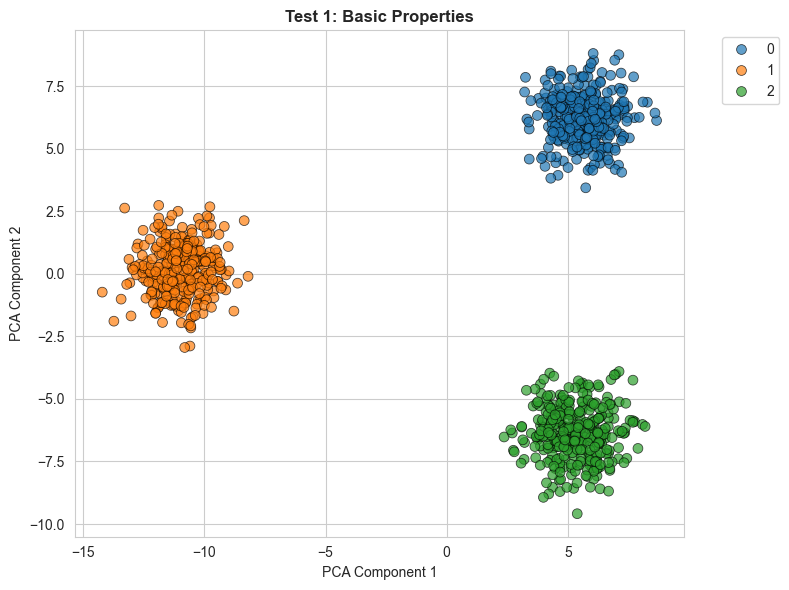

In [9]:
plot_simulation_2d(X, y, "Test 1: Basic Properties")

### Test 2: Imbalanced Clusters

In [10]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    cluster_proportions=[0.7, 0.2, 0.1]
)

In [11]:
X

,X1,X2,X3,X4,X5,X6,X7,X8
0,-1.086449,9.940502,5.605276,3.209300,0,0,0,2
1,-4.978510,1.516753,-2.417089,-5.225472,1,1,3,0
2,-2.004616,9.640824,3.400317,0.470299,0,0,2,1
3,-2.797746,8.230533,6.374815,1.116398,0,0,0,2
4,-3.360738,9.020559,3.108344,3.123437,0,1,0,2
...,...,...,...,...,...,...,...,...
995,-1.794588,6.964345,5.798953,1.636915,0,1,0,1
996,1.579037,3.872876,-9.702870,9.482291,1,1,3,0
997,-3.098530,8.555647,5.496581,3.650547,0,1,0,1
998,-1.863610,9.033667,2.319563,2.755800,0,1,0,1


In [12]:
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([700, 200, 100], dtype=int64))

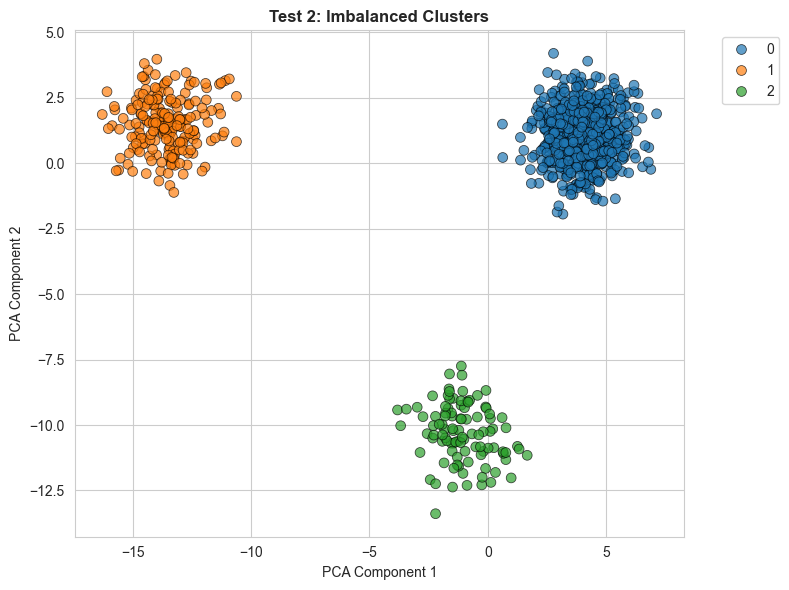

In [13]:
plot_simulation_2d(X, y, "Test 2: Imbalanced Clusters")

### Test 3: Separability

In [14]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    separation_factor=0.1
)

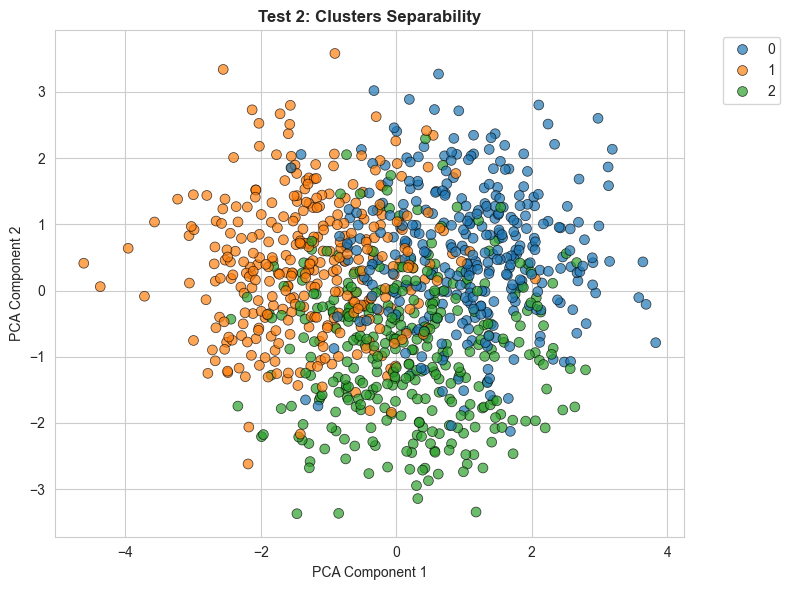

In [15]:
plot_simulation_2d(X, y, "Test 2: Clusters Separability")

In [16]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    separation_factor=0.2
)

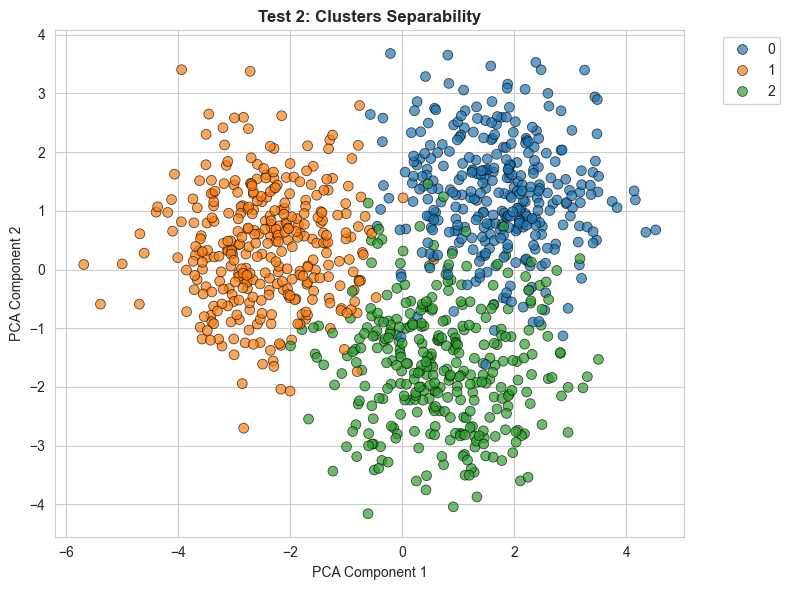

In [17]:
plot_simulation_2d(X, y, "Test 2: Clusters Separability")

In [18]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    separation_factor=0.4
)

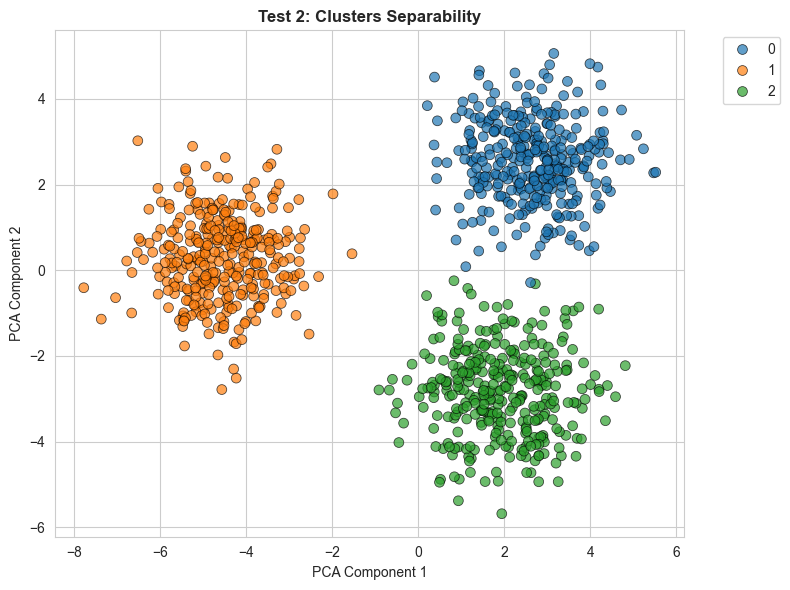

In [19]:
plot_simulation_2d(X, y, "Test 2: Clusters Separability")

In [20]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    separation_factor=1
)

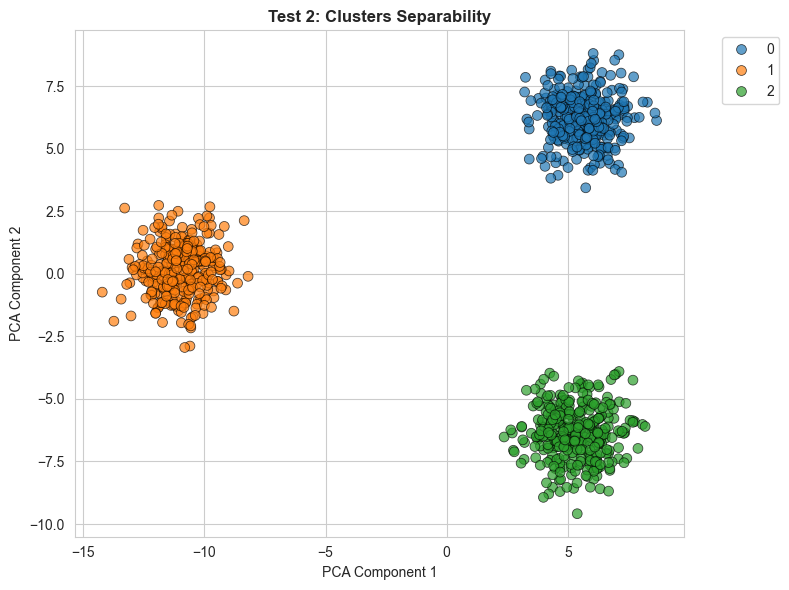

In [21]:
plot_simulation_2d(X, y, "Test 2: Clusters Separability")

In [22]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    separation_factor=3
)

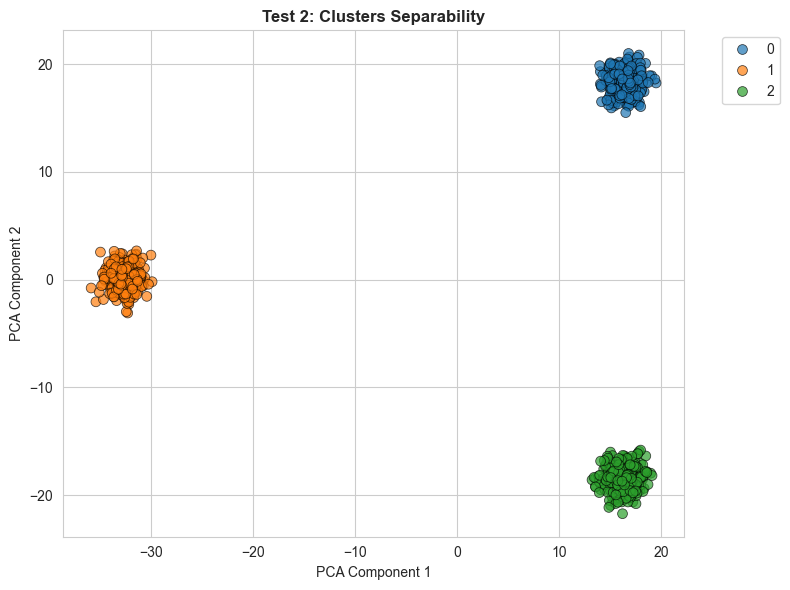

In [23]:
plot_simulation_2d(X, y, "Test 2: Clusters Separability")

### Test 4: Sphericity

In [24]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    anisotropy_factor=1
)

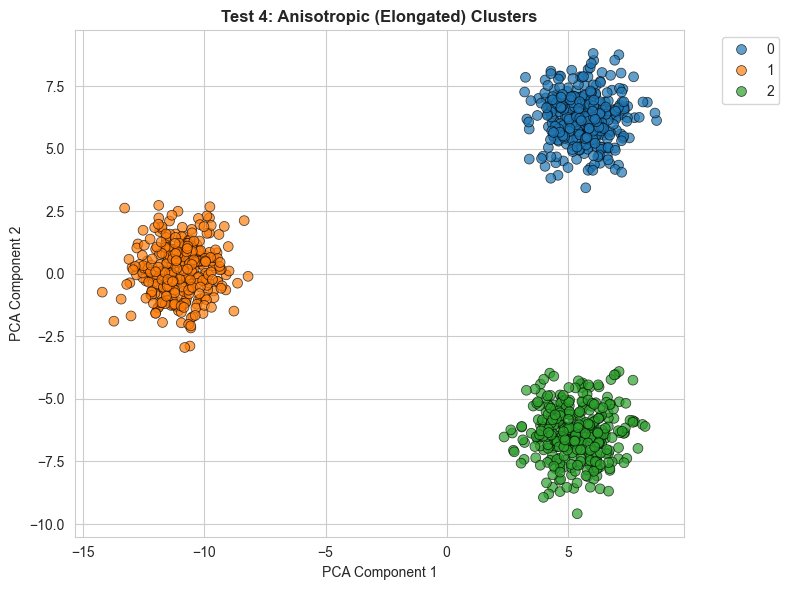

In [25]:
plot_simulation_2d(X, y, "Test 4: Anisotropic (Elongated) Clusters")

In [26]:
X[['X1', 'X2', 'X3', 'X4']].corr()

,X1,X2,X3,X4
X1,1.000000,0.125745,-0.732174,0.893221
X2,0.125745,1.000000,0.464748,0.355577
X3,-0.732174,0.464748,1.000000,-0.603156
X4,0.893221,0.355577,-0.603156,1.000000


In [27]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    anisotropy_factor=4
)

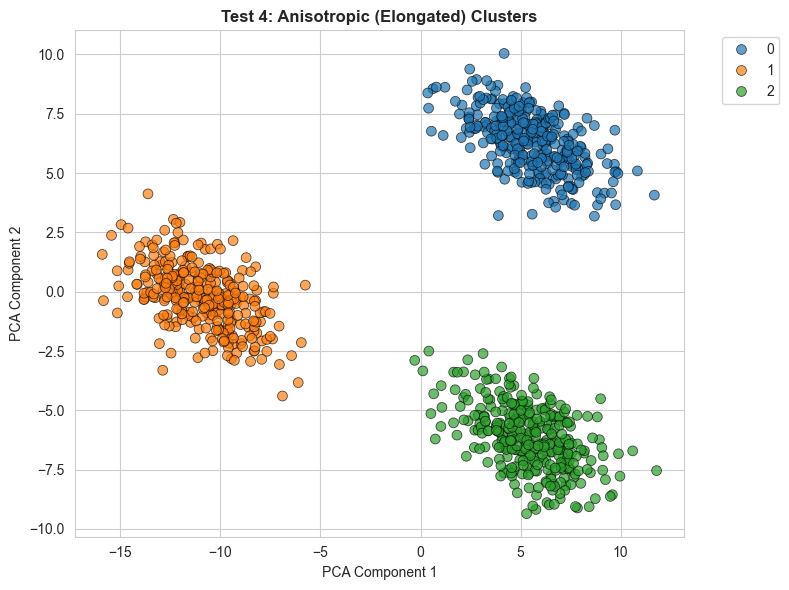

In [28]:
plot_simulation_2d(X, y, "Test 4: Anisotropic (Elongated) Clusters")

In [29]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    anisotropy_factor=6
)

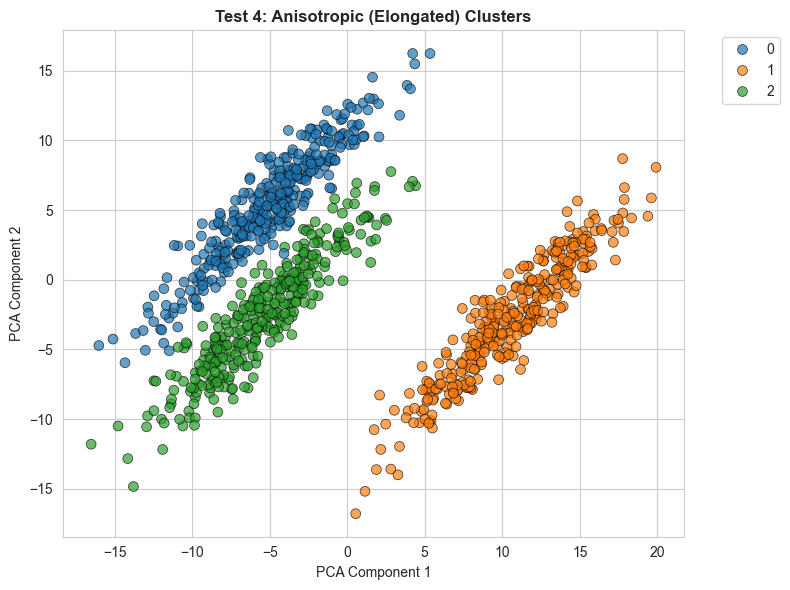

In [30]:
plot_simulation_2d(X, y, "Test 4: Anisotropic (Elongated) Clusters")

In [31]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    anisotropy_factor=8
)

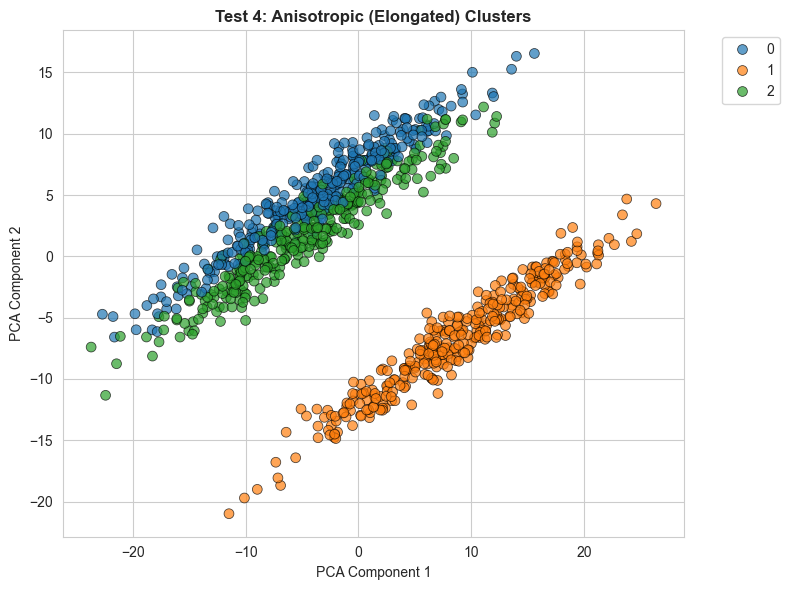

In [32]:
plot_simulation_2d(X, y, "Test 4: Anisotropic (Elongated) Clusters")

### Test 5: Outliers

In [35]:
X, y, out_idx = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    outlier_configs=[
        {'col_name': 'X1', 'prop_below': 0.05, 'prop_above': 0.05, 'sigma': 2}
    ],
    grouped_outliers_config=None, # Apagamos los agrupados
    return_outlier_idx=True,
    random_state=42
)

In [36]:
len(out_idx)

100

In [37]:
out_idx

array([  9,  29,  42,  47,  56,  59,  65,  70,  71,  76,  96, 101, 115,
       136, 139, 140, 143, 174, 191, 198, 210, 235, 277, 280, 299, 306,
       310, 312, 319, 321, 328, 330, 336, 340, 346, 370, 371, 385, 405,
       411, 413, 431, 439, 468, 499, 504, 508, 513, 521, 527, 535, 537,
       539, 549, 553, 567, 568, 570, 579, 580, 584, 601, 621, 626, 634,
       636, 638, 660, 678, 687, 737, 740, 760, 761, 773, 777, 806, 807,
       811, 814, 817, 837, 855, 859, 863, 883, 894, 899, 900, 901, 902,
       924, 938, 942, 947, 952, 973, 974, 975, 986])

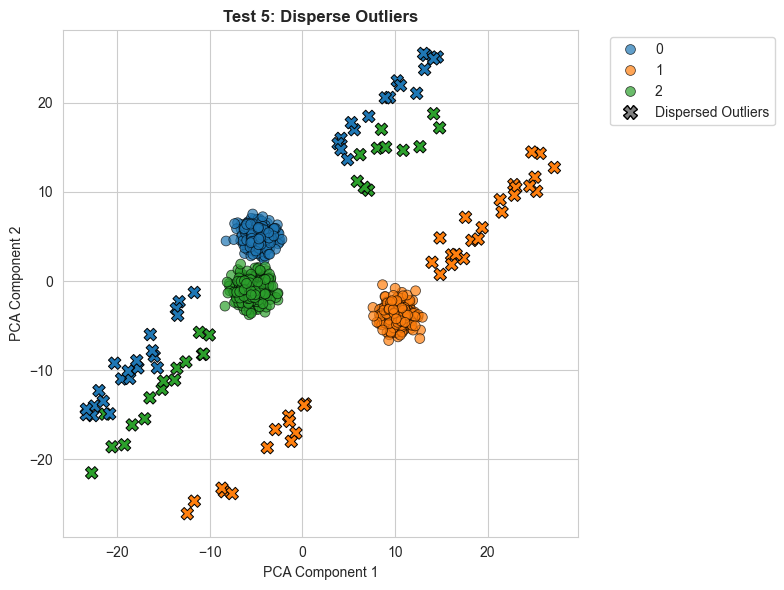

In [38]:
plot_simulation_2d(X, y, "Test 5: Disperse Outliers", out_idx)

In [39]:
X, y, out_idx = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    outlier_configs=[
        {'col_name': 'X1', 'prop_above': 0.05, 'sigma': 2},
        {'col_name': 'X2', 'prop_below': 0.05, 'sigma': 2}
    ],
    grouped_outliers_config=None, # Apagamos los agrupados
    return_outlier_idx=True,
    random_state=42
)

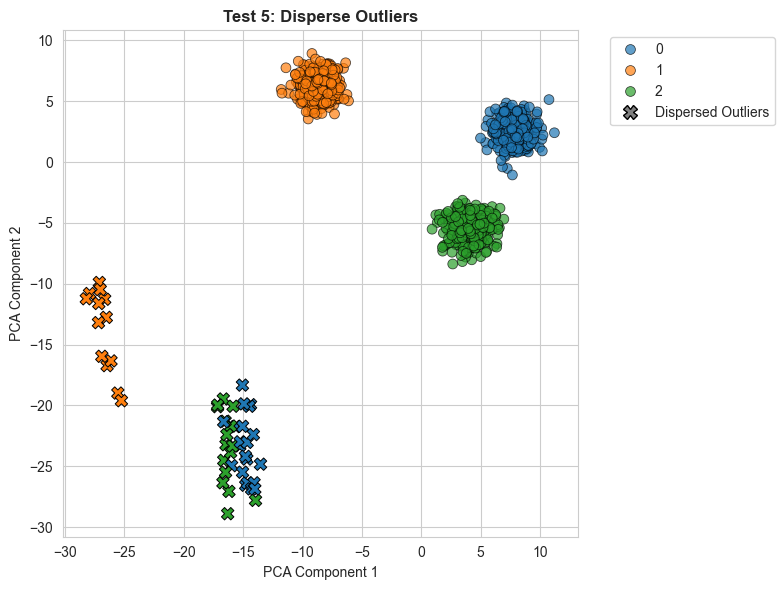

In [40]:
plot_simulation_2d(X, y, "Test 5: Disperse Outliers", out_idx)

In [45]:
X, y, out_idx = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    outlier_configs=None, # Apagamos los dispersos
    grouped_outliers_config={
        'n_outliers': 100, 'n_groups': 2, 'distance': 15.0
    },
    return_outlier_idx=True,
    random_state=42
)


In [42]:
len(out_idx)

100

In [43]:
out_idx

array([ 21,  36,  43,  45,  56,  69,  70,  93, 109, 116, 126, 145, 156,
       157, 172, 181, 208, 221, 229, 251, 263, 268, 269, 283, 307, 322,
       325, 326, 341, 345, 349, 380, 381, 382, 390, 397, 414, 420, 441,
       446, 450, 456, 461, 472, 478, 481, 487, 489, 501, 519, 529, 533,
       534, 540, 555, 582, 588, 599, 633, 664, 671, 684, 686, 695, 703,
       705, 706, 708, 709, 721, 722, 724, 741, 759, 773, 776, 786, 787,
       803, 817, 829, 830, 835, 843, 852, 861, 865, 868, 869, 880, 881,
       887, 901, 909, 911, 924, 934, 979, 987, 992], dtype=int64)

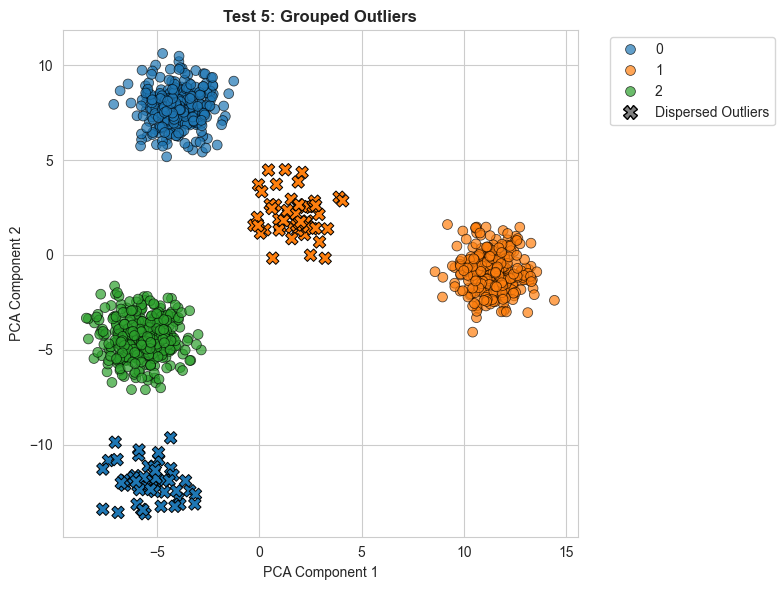

In [46]:
plot_simulation_2d(X, y, "Test 5: Grouped Outliers", out_idx)

### Test 6: Redundancy/Correlation

In [47]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    n_redundant=1
)

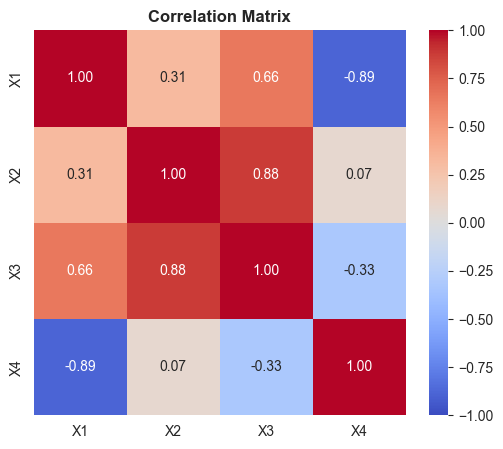

In [51]:
quant_features = ['X1', 'X2', 'X3', 'X4']
plt.figure(figsize=(6, 5))
sns.heatmap(pd.DataFrame(X[quant_features]).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix", fontweight='bold')
plt.show()

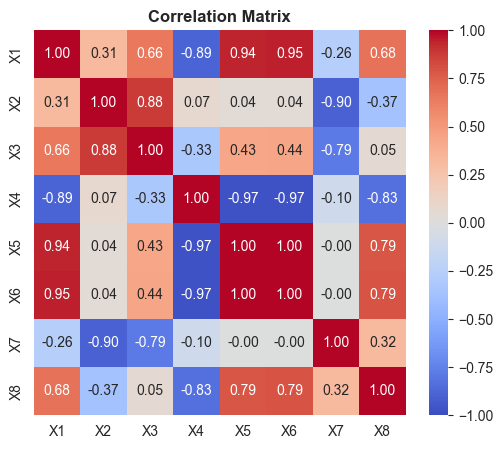

In [52]:
plt.figure(figsize=(6, 5))
sns.heatmap(pd.DataFrame(X).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix", fontweight='bold')
plt.show()

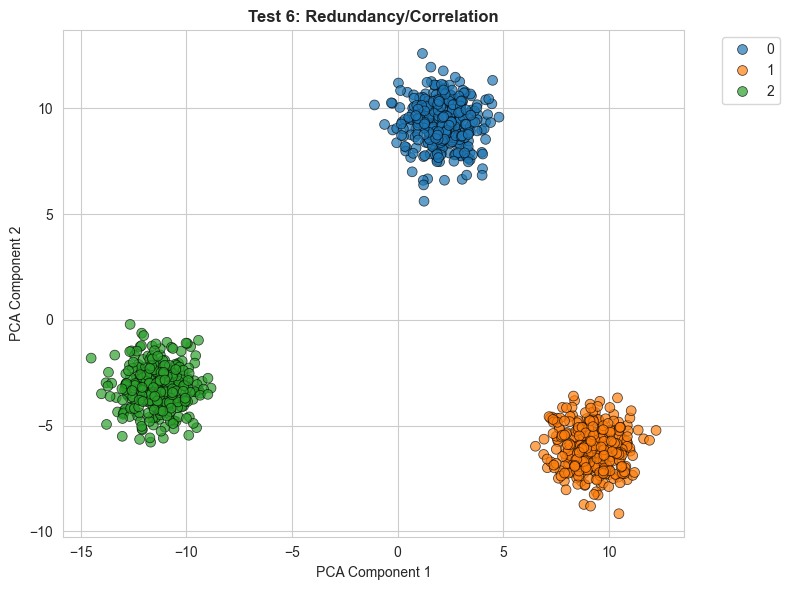

In [54]:
plot_simulation_2d(X, y, "Test 6: Redundancy/Correlation")

In [55]:
X, y = generate_simulation(
    n_samples=1000, centers=3, n_features=8,
    feature_types={'n_binary': 2, 'n_multiclass': 2, 'n_bins_multiclass': 4},
    n_redundant=2
)

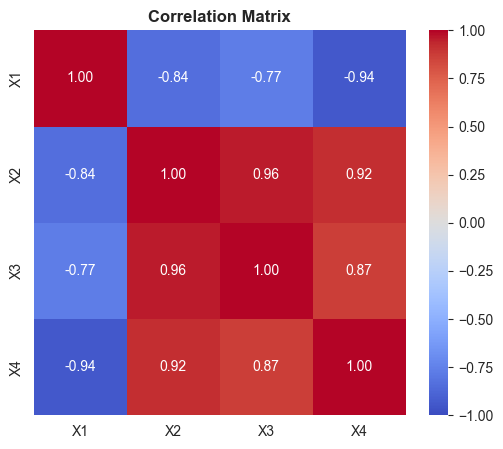

In [56]:
quant_features = ['X1', 'X2', 'X3', 'X4']
plt.figure(figsize=(6, 5))
sns.heatmap(pd.DataFrame(X[quant_features]).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix", fontweight='bold')
plt.show()

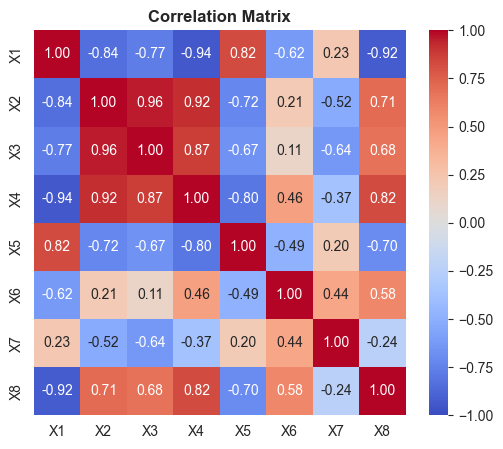

In [57]:
plt.figure(figsize=(6, 5))
sns.heatmap(pd.DataFrame(X).corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix", fontweight='bold')
plt.show()

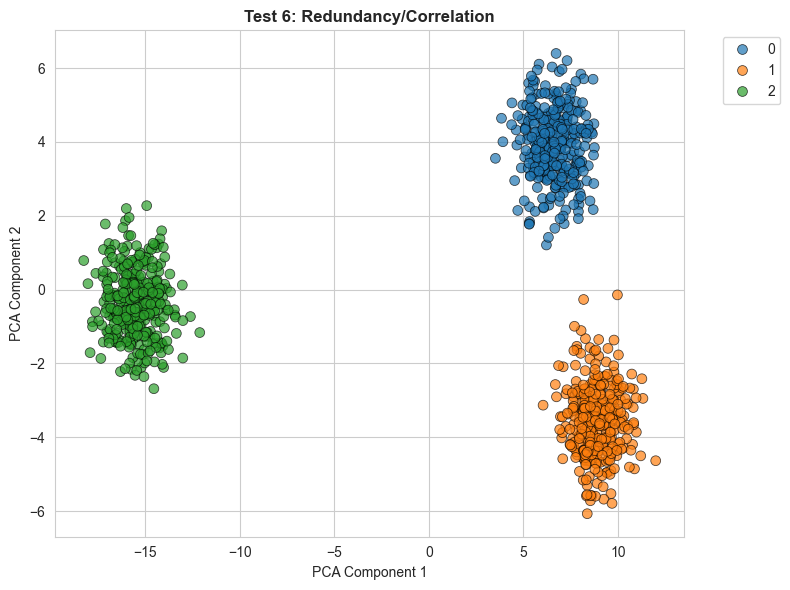

In [58]:
plot_simulation_2d(X, y, "Test 6: Redundancy/Correlation")